<a href="https://colab.research.google.com/github/blankqspace/homework_compling_course/blob/main/gpt_homework_Artamonova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание № 9

# Задание 1 (10 баллов)

Визуализируйте attention для одного любого текста после нескольких последовательных эпох обучения, чтобы проанализировать как модель учится понимать текст.
Для этого вам понадобится так изменить код модели из семинара, чтобы Block класс возвращал attention активации (последнее значение wei), а также все остальные классы, которые вызывают Block, чтобы они ожидали, что модель вернет не только out но и wei. В самом верхнеуровневом классе BigramLanguageModel вы можете добавить атрибут last_attentions и в forward перезаписывать его значения последним значением attention (но можно придумать и другой способ). После каждой эпохи вызовите модель на одном примере из датасета и сохраните last_attentions во внешнюю переменную, чтобы потом отдельно заняться визуализацией. Визуализируйте attentions как heatmap'ы (например в searborn). У вас будет attention матрица для каждого слоя и для каждого head в модели. Для каждой нужно будет сделать свой хитмап.

Напишите короткую интерпретацию полученных результатов: какие паттерны в матрицах внимания вы видите? как эти паттерны отличаются между слоями? как они меняются с каждой эпохой?
Постарайтесь найти какое-то хорошее предложение, для которого у вас заранее есть какое-то представление о связях между словами и которое вы сможете сравнить со скорами внимания (например, какую синтаксическую конструкцию)

Должно получиться что-то похожее на (только несколько для каждой эпохи)
![](https://www.kdnuggets.com/wp-content/uploads/How_to_Visualize_Model_Internals_and_Attention_in_Hugging_Face_Transformers_3.png)

In [6]:
%pip install rusenttokenize
%pip install tokenizers

In [7]:
import pandas as pd
from rusenttokenize import ru_sent_tokenize

data = pd.read_csv('https://github.com/mannefedov/compling_nlp_hse_course/raw/refs/heads/master/data/lenta_40k.csv.zip')
sentences = []
for text in data.text.values:
    sentences.extend(ru_sent_tokenize(text))

f = open('corpus.txt', 'w')
for sent in sentences:
    f.write(sent + '\n')
f.close()

sentences = open('corpus.txt').read().splitlines()

In [8]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers import decoders

tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(special_tokens=["[PAD]", "[BOS]", "[EOS]"], end_of_word_suffix='</w>')
tokenizer.train(files=["corpus.txt"], trainer=trainer)
tokenizer.save('tokenizer')
tokenizer.decoder = decoders.BPEDecoder()

def encode(text, tokenizer):
    return [tokenizer.token_to_id('[BOS]')] + tokenizer.encode(text).ids + [tokenizer.token_to_id('[EOS]')]

PAD_IDX = tokenizer.token_to_id('[PAD]')

In [18]:
vocab_size = tokenizer.get_vocab_size()

In [9]:
import torch

In [10]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, sentences, tokenizer, max_len=32):
        # каждое предложение преобразуется в последовательность индексов
        # а списки преобразуются в тензоры
        self.encoded_texts = [torch.LongTensor(encode(sent, tokenizer)[-max_len:]) for sent in sentences]
        # чтобы составить один общий обучающий тензор нужно сравнять длины последовательностей отдельных текстов
        # в торче не такая удобная функция паддинга, поэтому транкация (отрезание лишнего) происходит уже выше
        self.X = torch.nn.utils.rnn.pad_sequence(self.encoded_texts, padding_value=PAD_IDX, batch_first=True)
        self.length = len(self.encoded_texts)

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        # обучающий пример для GPT составляется из одного текста
        # x - это все токены кроме последнего
        # y - это все токены кроме первого
        # другими словами, y это x со сдвигом вправо
        # каждый отдельный элемент в y - следующий токен для соответствующего элемента в x
        # tokens = [1,2,3,4,5,0]
        # x = [1,2,3,4,5]
        # y = [2,3,4,5,0]

        # 1 -> 2
        # 1,2 -> 3
        # 1,2,3 -> 4
        # 1,2,3,4 -> 5
        # teacher forcing

        x = self.X[index][:-1]
        y = self.X[index][1:]

        # чтобы не учитывать паддинг нам нужно создать маску
        mask = x!=PAD_IDX

        return x, y, mask

In [11]:
n = int(0.9*len(sentences)) # first 90% will be train, rest val
sentences_train = sentences[:n]
sentences_val = sentences[n:]

MAX_LEN = 64

training_set = Dataset(sentences_train, tokenizer, MAX_LEN)
val_set = Dataset(sentences_val, tokenizer, MAX_LEN)

training_generator = torch.utils.data.DataLoader(training_set, batch_size=200, shuffle=True, )
val_generator = torch.utils.data.DataLoader(val_set, batch_size=200, shuffle=False)

In [12]:
# hyperparameters
block_size = MAX_LEN # what is the maximum context length for predictions?
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_embd = 64 # размерность эмбеддингов и векторов внутри трансформера
#ffn_hid_dim = n_embd * 4
n_head = 4
n_layer = 4
dropout = 0.0

In [15]:
import torch.nn as nn
import torch.nn.functional as F

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        if mask is not None:
            wei = wei.masked_fill(~mask.unsqueeze(1), float('-inf'))
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out, wei

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        head_outs = []
        head_weights = []

        for h in self.heads:
            out, wei = h(x, mask)
            head_outs.append(out)
            head_weights.append(wei)

        out = torch.cat(head_outs, dim=-1)
        out = self.dropout(self.proj(out))

        # shape: (num_heads, B, T, T)
        attentions = torch.stack(head_weights)

        return out, attentions

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, inp):
        x, mask = inp

        sa_out, attentions = self.sa(self.ln1(x), mask)
        x = x + sa_out
        x = x + self.ffwd(self.ln2(x))

        return (x, mask), attentions

In [59]:
class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)

        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head) for _ in range(n_layer)]
        )

        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

        self.last_attentions = None

    def forward(self, idx, targets=None, mask=None):

        B,T = idx.shape

        tok = self.token_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=device))

        x = tok + pos

        all_attn = []

        for block in self.blocks:
            (x, mask), attn = block((x, mask))
            all_attn.append(attn.detach().cpu())

        self.last_attentions = all_attn

        x = self.ln_f(x)
        logits = self.head(x)
        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            loss = F.cross_entropy(
                logits.view(B*T, C),
                targets.view(B*T),
                ignore_index=PAD_IDX
            )

        return logits, loss

    def generate(self, idx, max_new_tokens, stop_token):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)# (B, 1)
            if idx_next == stop_token:
                break
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx


In [53]:
model = GPTLanguageModel(vocab_size)
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

4.073392 M parameters


In [60]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [71]:
def train(model, iterator, optimizer, print_every=10):
    epoch_loss = []
    model.train()

    for i, (xs, ys, mask) in enumerate(iterator):
        optimizer.zero_grad()
        logits, loss = model(xs.to(device), ys.to(device), mask.to(device))

        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

        if not (i+1) % print_every:
            print(f'Loss: {torch.Tensor(epoch_loss).mean(-1)}')

    return torch.Tensor(epoch_loss).mean(-1)

def evaluate(model, iterator):
    epoch_loss = []
    model.eval()
    with torch.no_grad():
        for xs, ys, mask in iterator:
            logits, loss = model(xs.to(device), ys.to(device), mask.to(device))
            epoch_loss.append(loss.item())

    return torch.Tensor(epoch_loss).mean(-1)

In [72]:
example_x, example_y, example_mask = val_set[0]
example_x = example_x.unsqueeze(0).to(device)
example_mask = example_mask.unsqueeze(0).to(device)
saved_attentions = []

In [73]:
train_losses = []
eval_losses = []

EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch}")

    train_loss = train(model, training_generator, optimizer, print_every=100)
    train_losses.append(train_loss)

    eval_loss = evaluate(model, val_generator)
    eval_losses.append(eval_loss)
    print(f"Train loss: {train_loss.item():.4f} | Eval loss: {eval_loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        logits, _ = model(example_x, mask=example_mask)

        # сохраняем все attention слоёв и хедов
        saved_attentions.append([layer.clone() for layer in model.last_attentions])

    for _ in range(3):
        pred = model.generate(
            torch.LongTensor([[tokenizer.token_to_id('[BOS]')]]).to(device),
            max_new_tokens=200,
            stop_token=tokenizer.token_to_id('[EOS]')
        )
        decoded = tokenizer.decoder.decode([tokenizer.id_to_token(i) for i in pred[0].detach().cpu().numpy()][1:-1])
        print(decoded)



Epoch 0
Loss: 4.507718086242676
Loss: 4.503652095794678
Loss: 4.508500099182129
Loss: 4.510866165161133
Loss: 4.513267517089844
Loss: 4.516358852386475
Loss: 4.519148349761963
Loss: 4.522260665893555
Loss: 4.525076389312744
Loss: 4.525815486907959
Loss: 4.526731014251709
Loss: 4.526905536651611
Loss: 4.527647495269775
Loss: 4.528028964996338
Loss: 4.528707504272461
Loss: 4.529099941253662
Loss: 4.530089378356934
Loss: 4.5308356285095215
Loss: 4.531935214996338
Loss: 4.532900810241699
Loss: 4.533613681793213
Loss: 4.534275531768799
Train loss: 4.5345 | Eval loss: 4.6882
Как передает РИА Новости , в январе 2015 года Совбрат , убит террористического исламистского расследования
Также он уточнил , что делает флялику в целом , даже если сотни человек находится на новом месте - около 56 тысяч благотворительных комплексов , включая страны , танки и другие и уговаривающие на места и объекты Грегионы
Напомним , что полицейские присмотрели действия правительственных войск , и военнослужащих в те

In [98]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_attention_words_only(attentions, tokens, epoch, sentence=None):
    # оставляем только "настоящие" слова, убираем PAD
    valid_idx = [i for i, t in enumerate(tokens) if t not in ['[PAD]', '[BOS]', '[EOS]']]
    filtered_tokens = [tokens[i] for i in valid_idx]

    for layer_i, layer in enumerate(attentions):
        num_heads = layer.shape[0]
        for head_i in range(num_heads):
            # attention для батча 0, только слова
            attn = layer[head_i][0].cpu().numpy()
            attn = attn[np.ix_(valid_idx, valid_idx)]

            plt.figure(figsize=(6,5))
            ax = sns.heatmap(
                attn,
                xticklabels=filtered_tokens,
                yticklabels=filtered_tokens,
                cmap="viridis"
            )
            # повернем x-метки и уменьшим шрифт
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

            plt.title(f"Epoch {epoch} | Layer {layer_i} | Head {head_i}", fontsize=10)
            plt.tight_layout()
            plt.show()


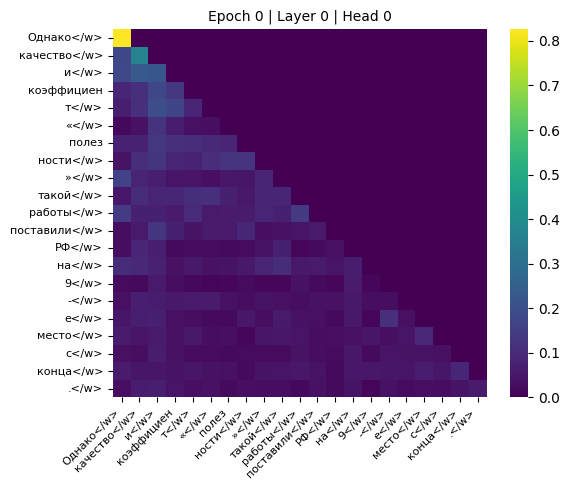

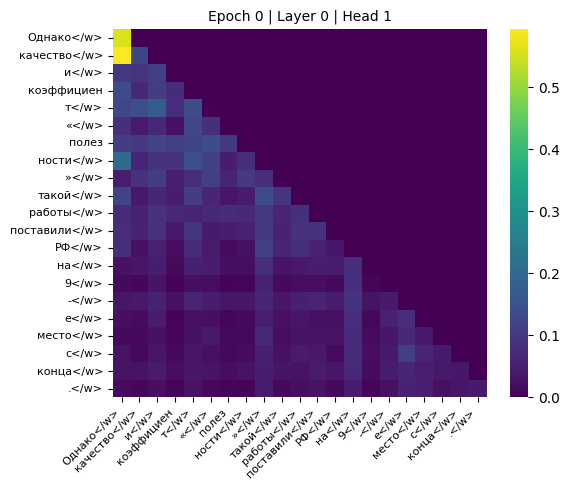

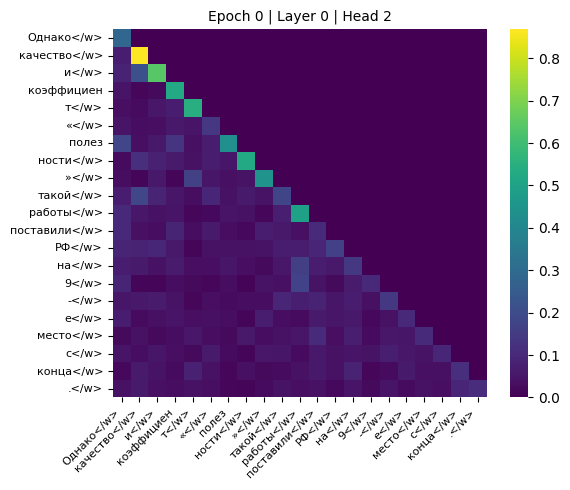

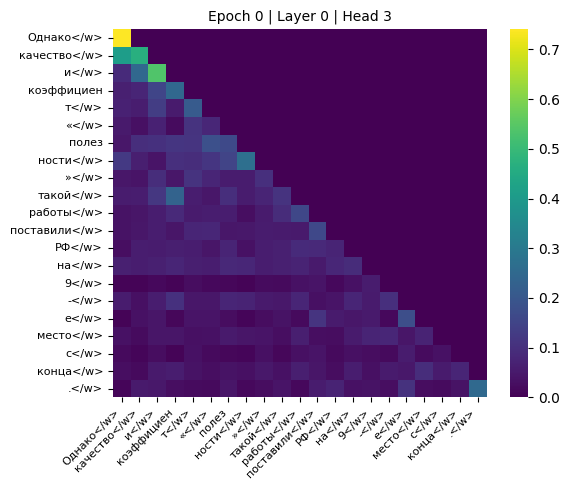

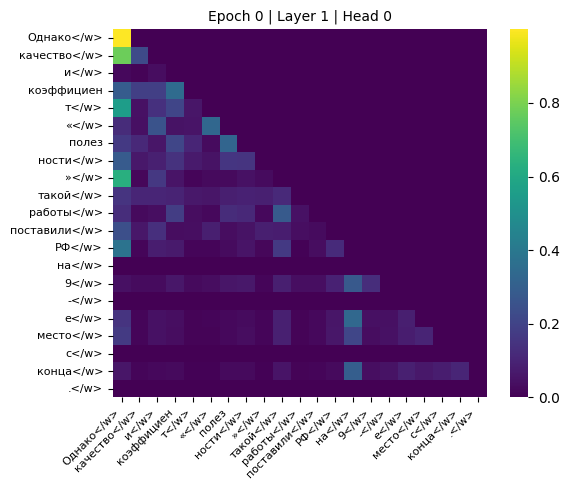

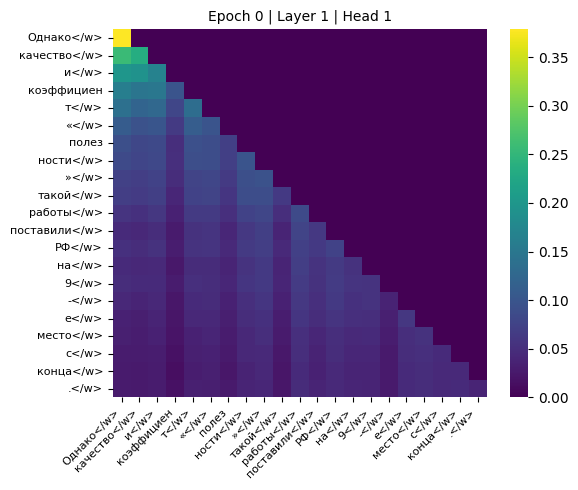

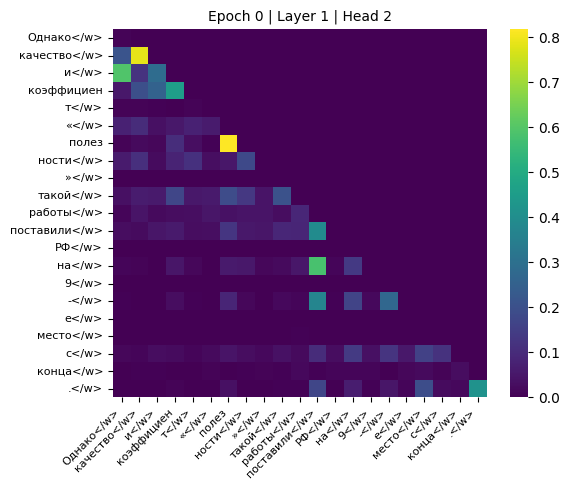

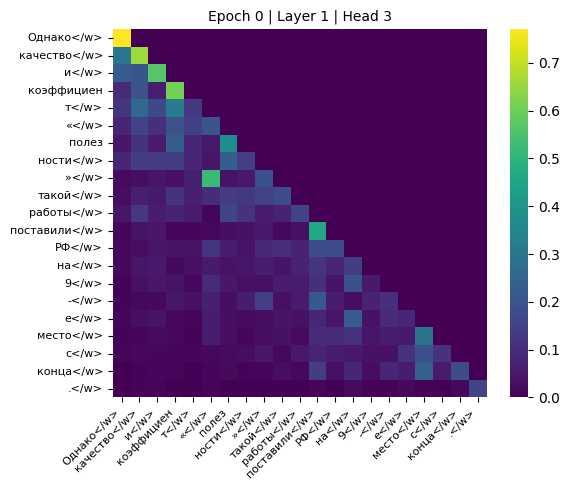

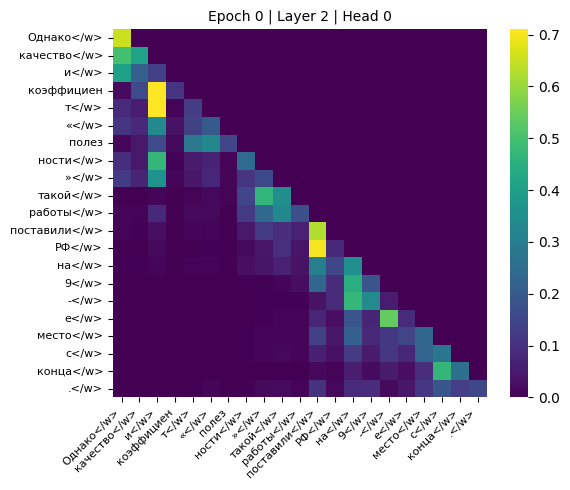

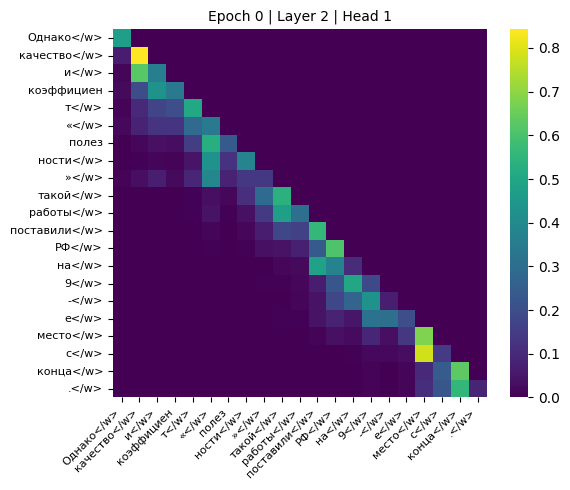

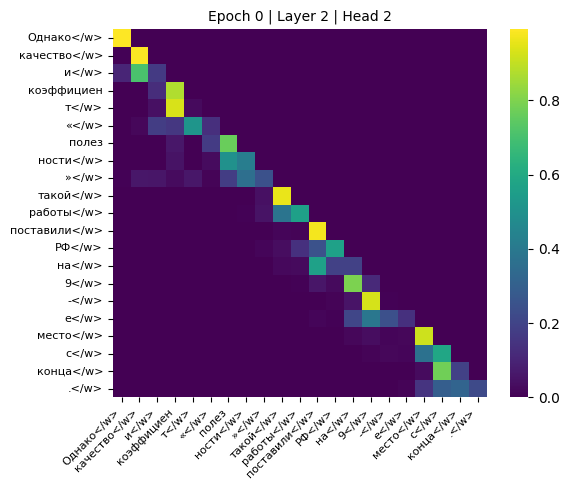

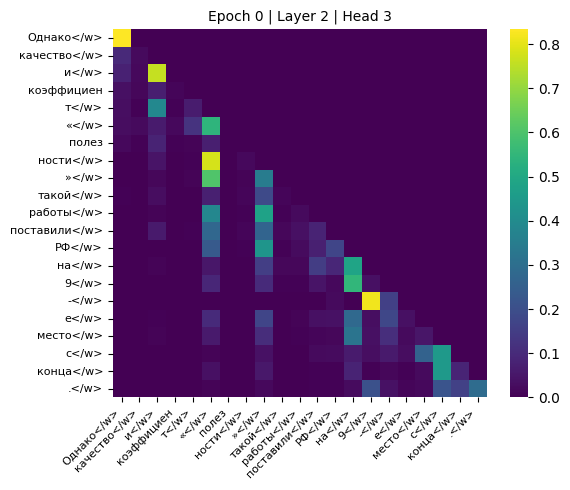

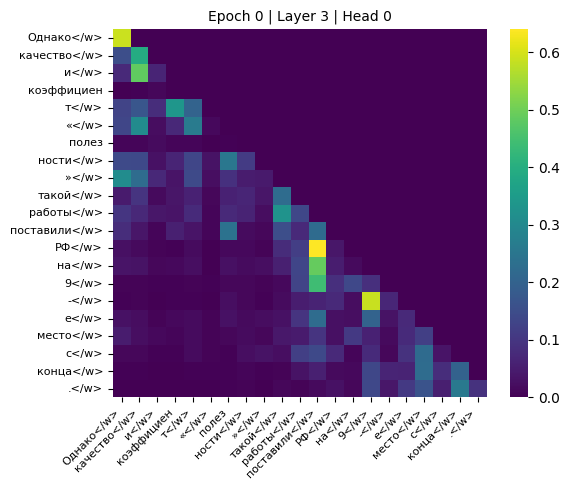

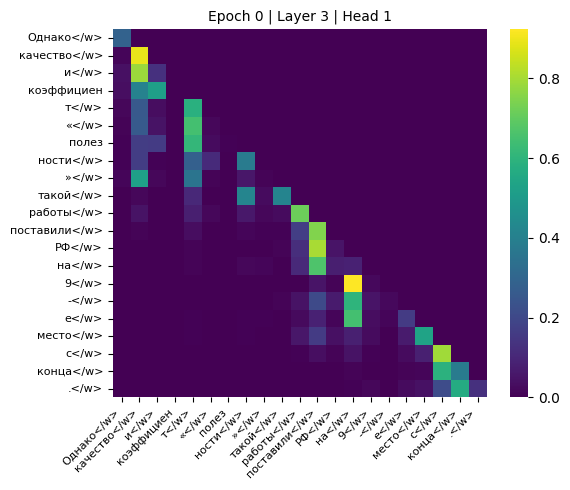

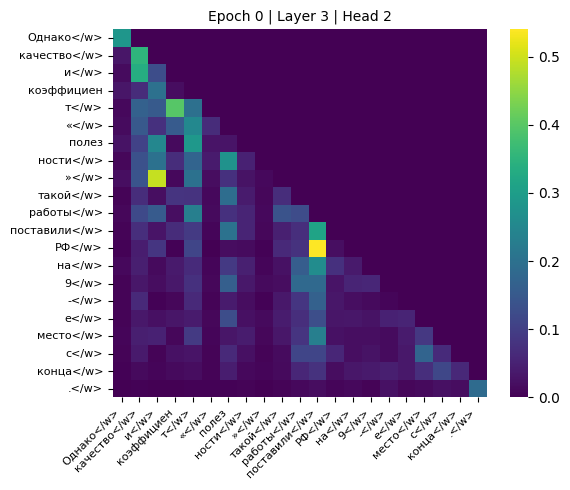

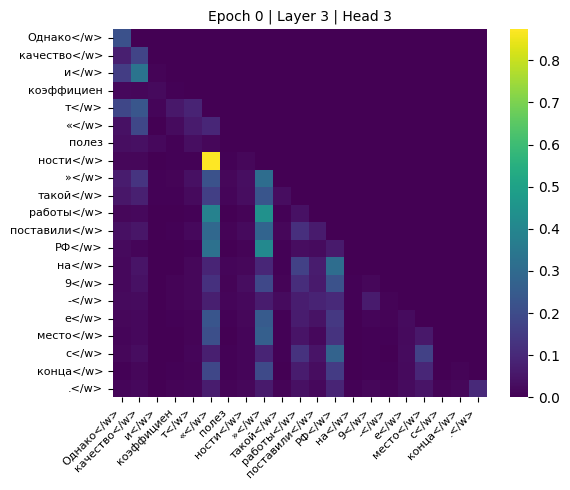

In [99]:
for epoch in [0]:
    plot_attention_words_only(saved_attentions[epoch], tokens, epoch, sentence=example_sentence)

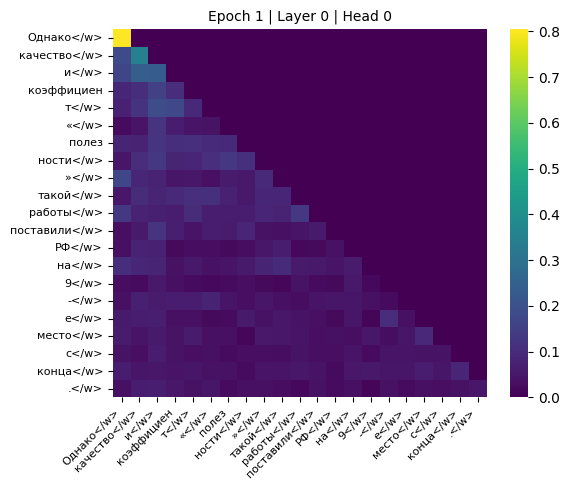

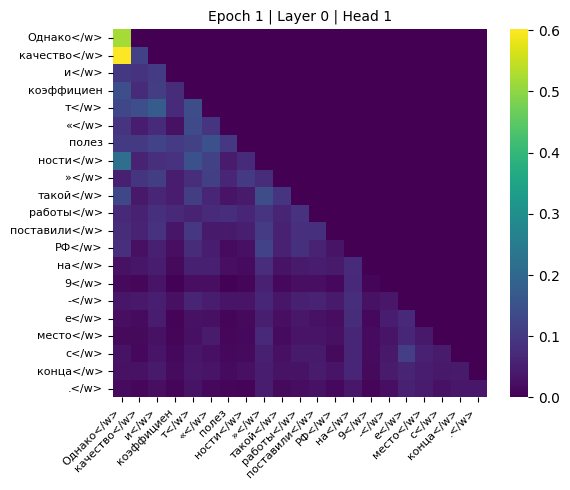

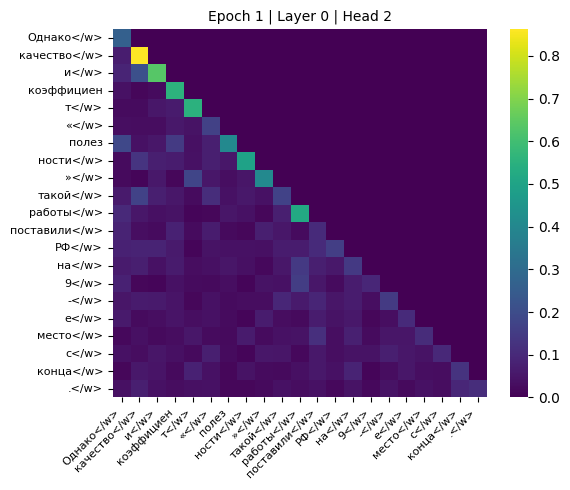

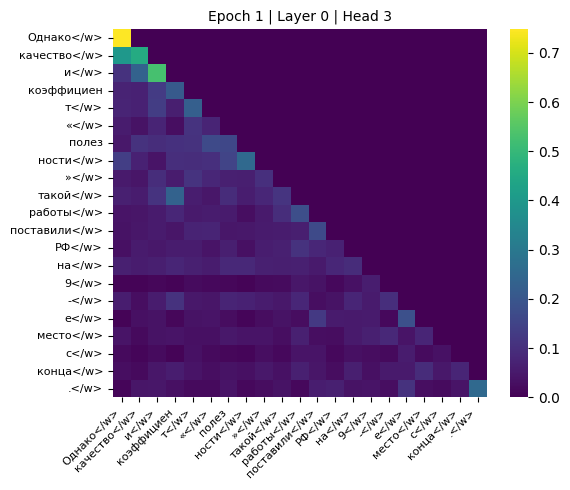

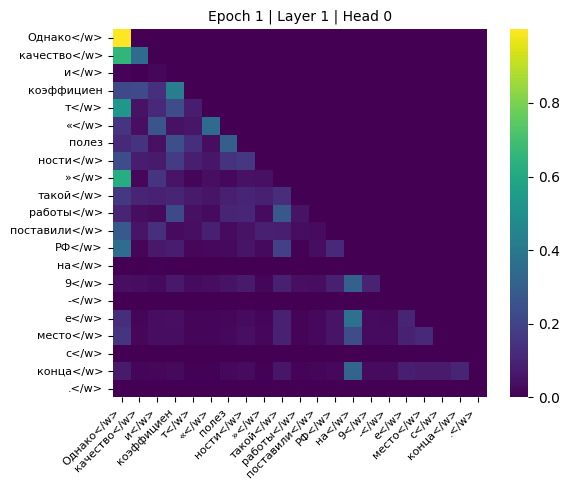

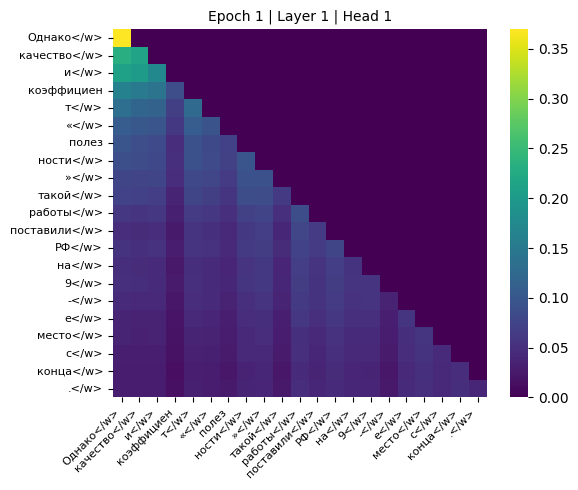

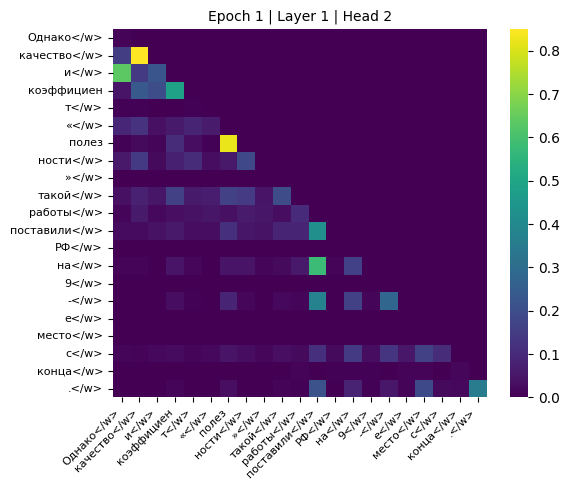

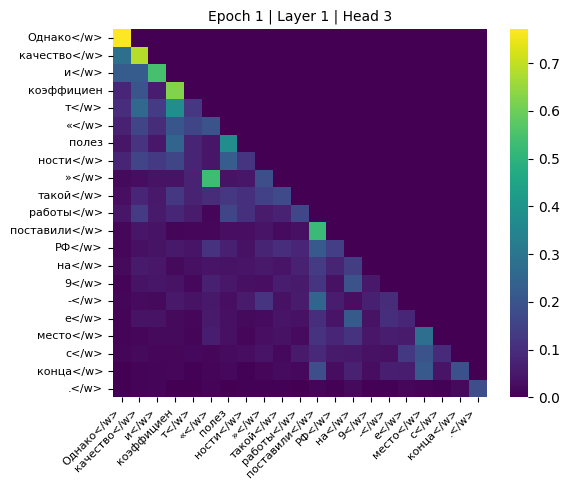

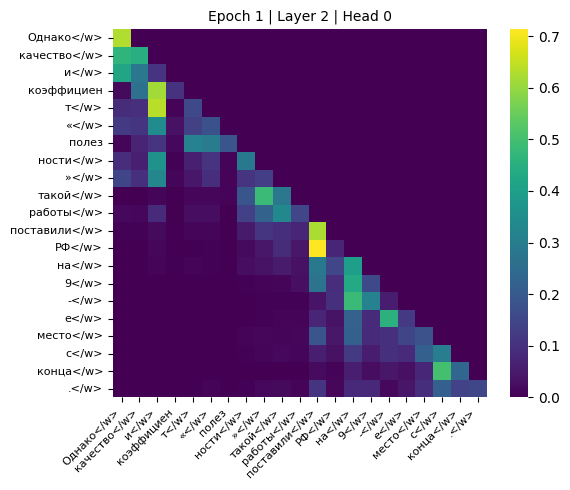

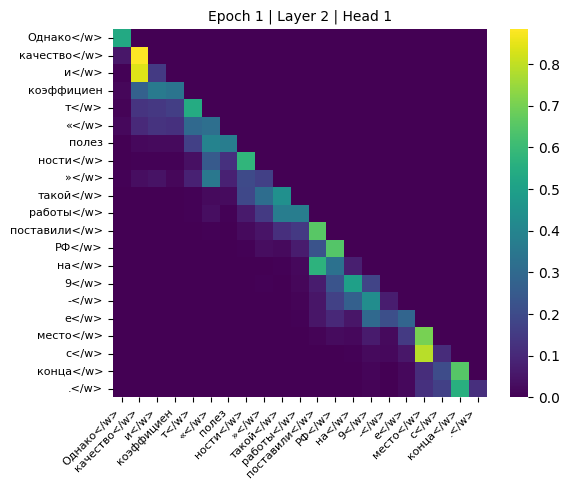

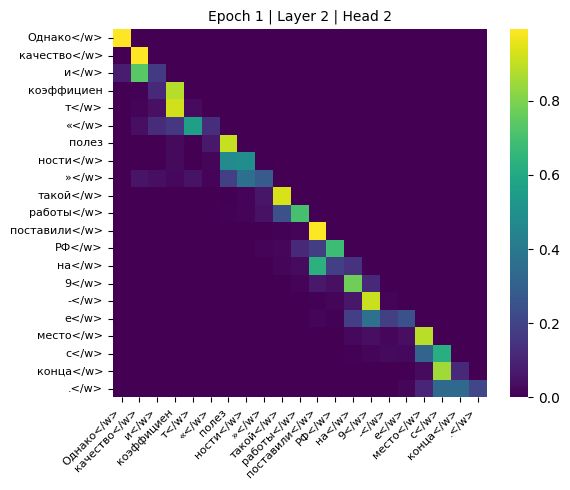

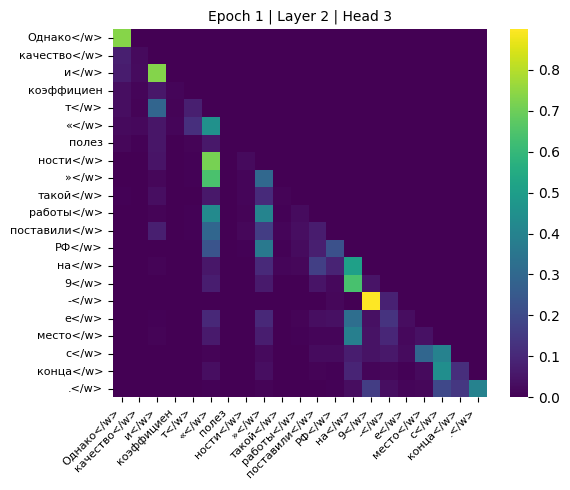

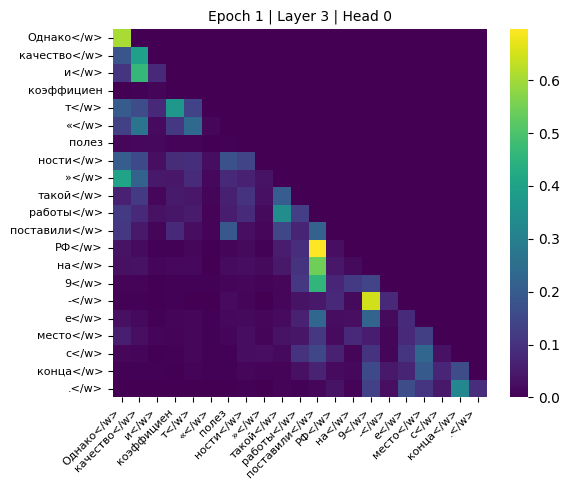

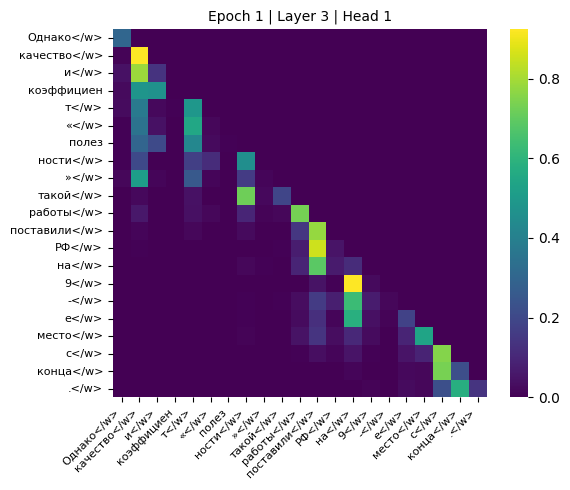

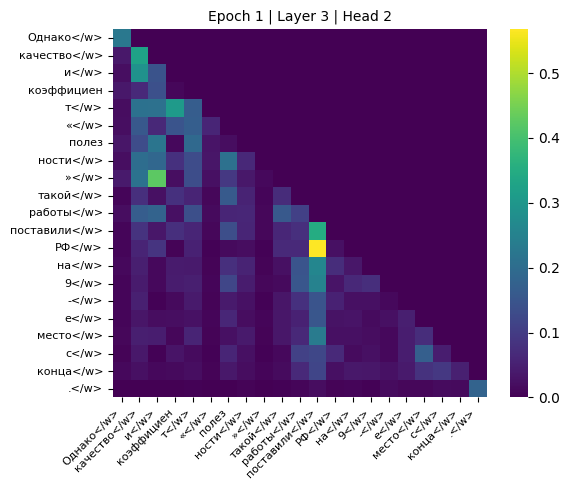

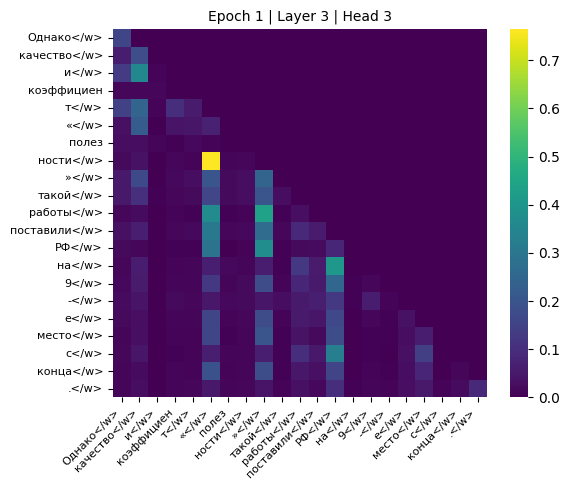

In [100]:
for epoch in [1]:
    plot_attention_words_only(saved_attentions[epoch], tokens, epoch, sentence=example_sentence)

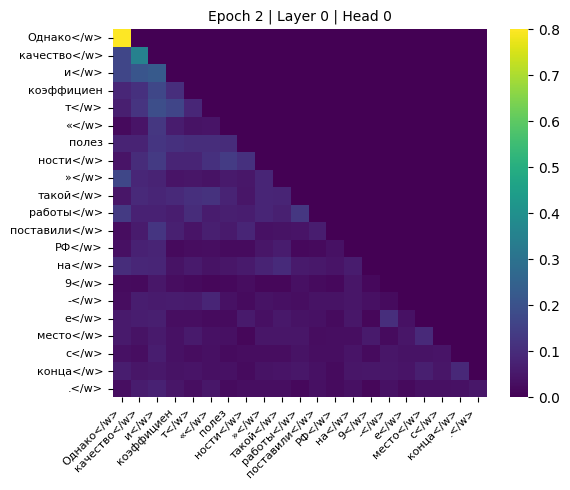

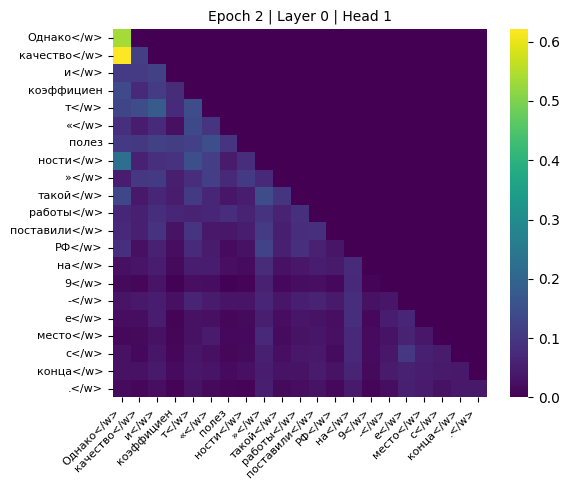

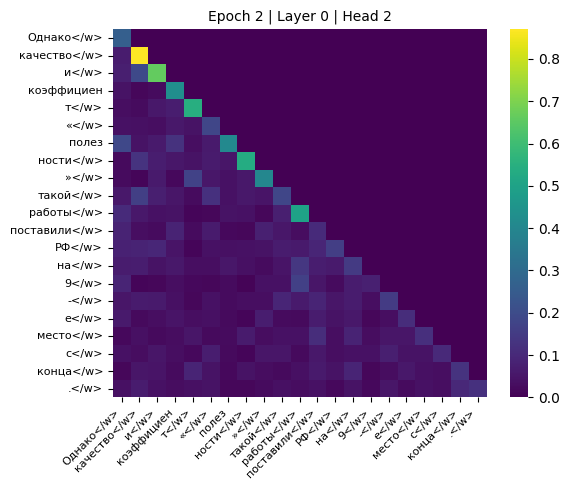

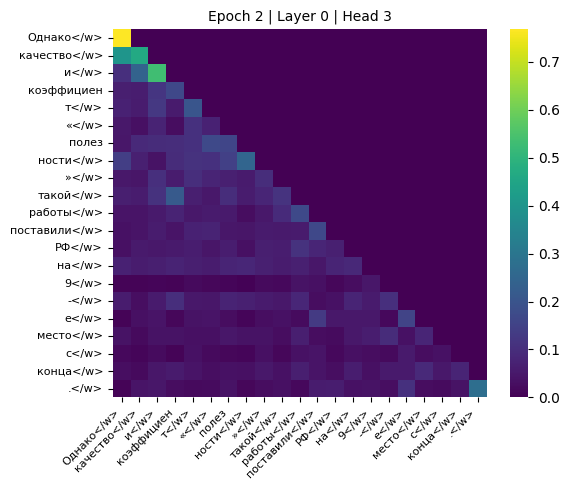

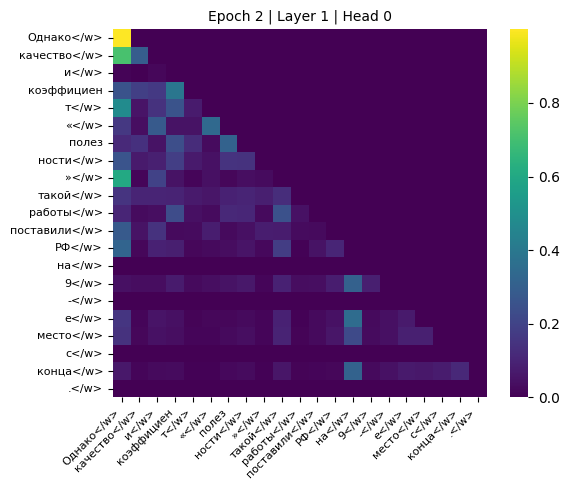

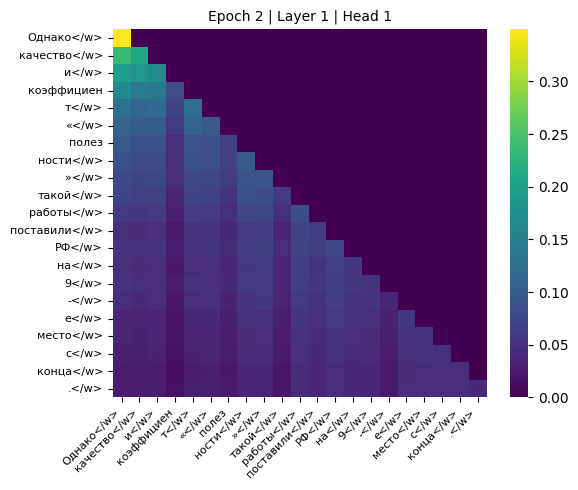

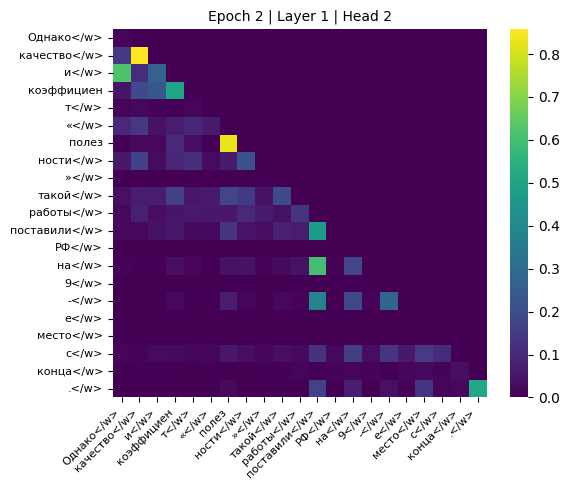

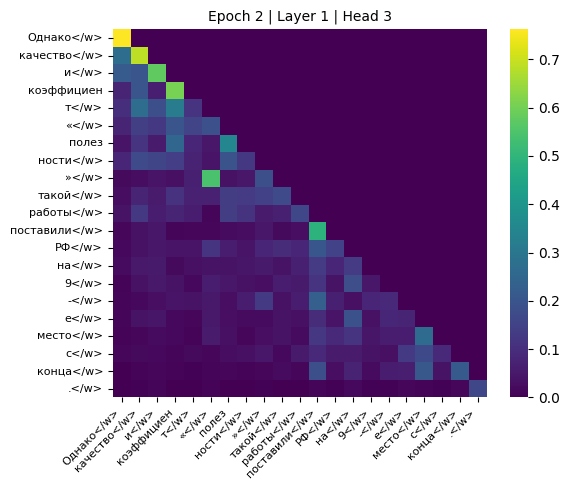

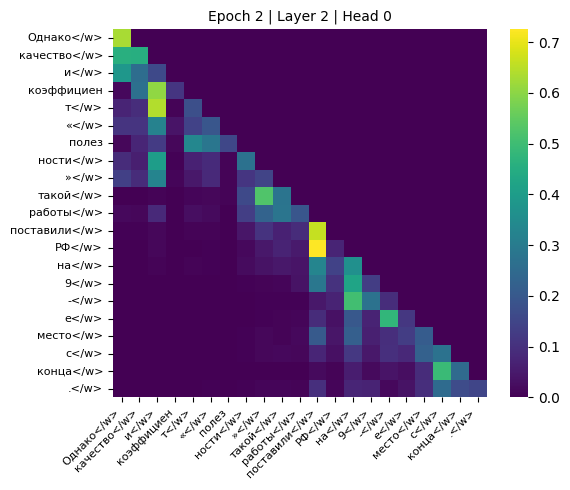

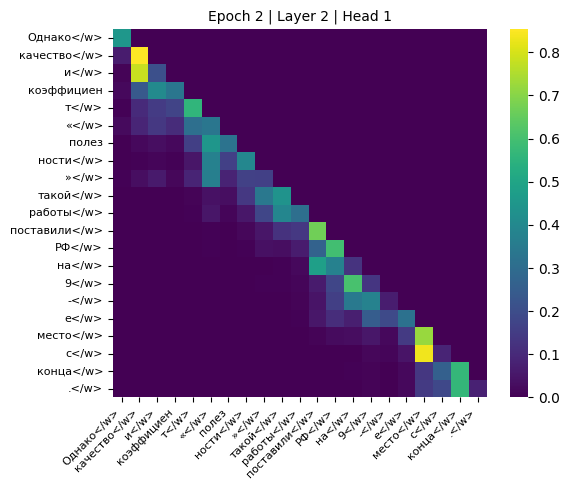

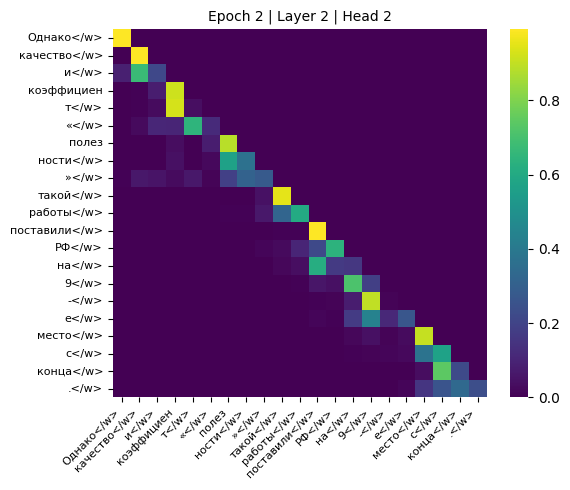

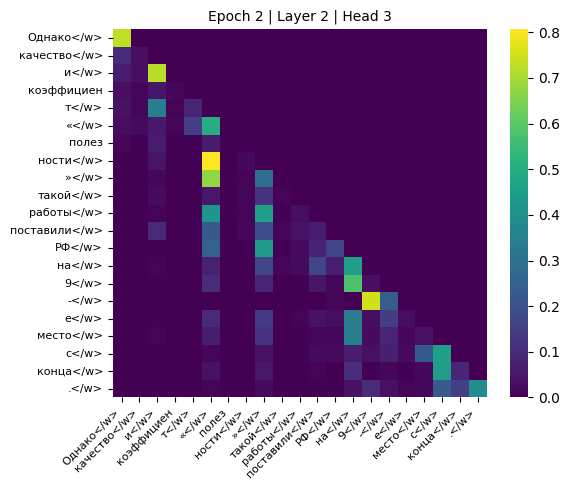

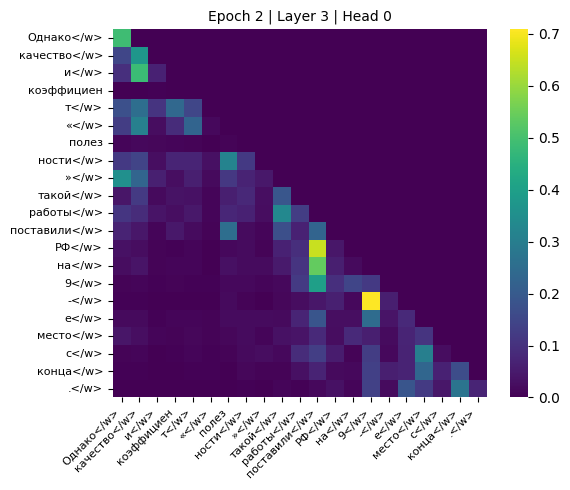

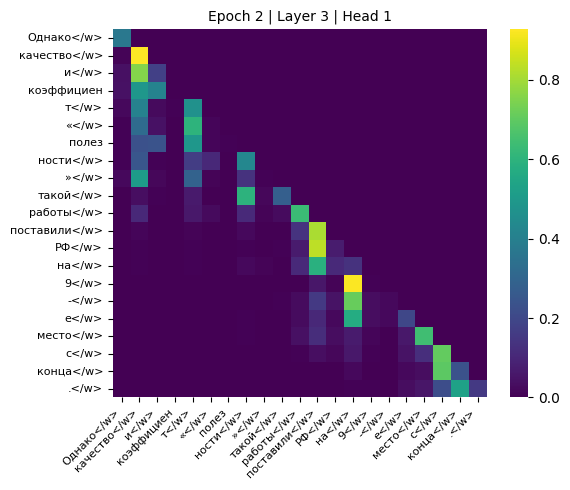

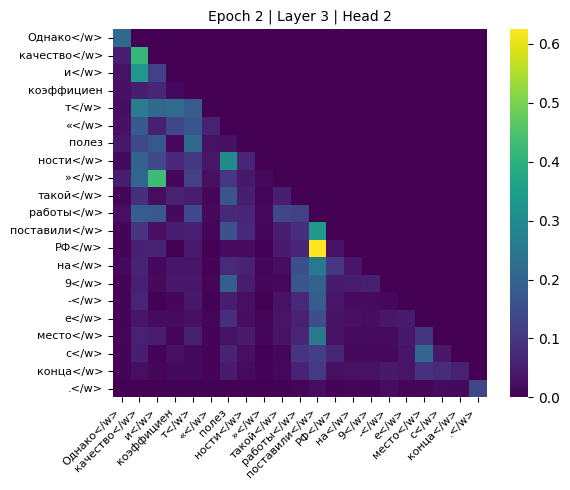

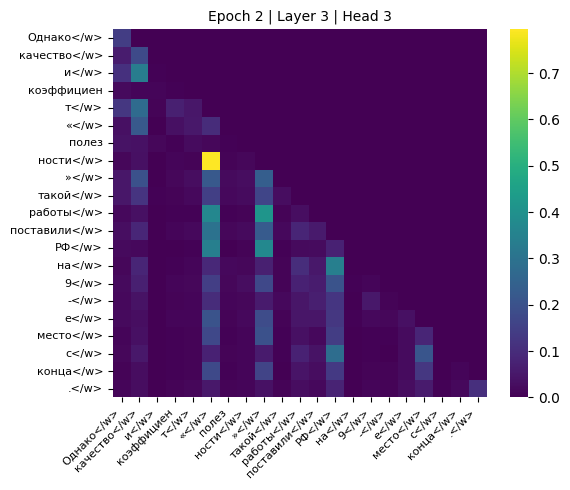

In [101]:
for epoch in [2]:
    plot_attention_words_only(saved_attentions[epoch], tokens, epoch, sentence=example_sentence)